In [1]:
#pip install xskillscore

In [2]:
#pip install  climetlab

In [3]:
#pip install --upgrade fair-research-login 

In [4]:
#pip install geocat.viz

In [5]:
#conda install -c conda-forge xcdat

In [6]:
#pip install numpy

In [7]:
#pip install tropycal

In [8]:
#pip install climetlab

In [9]:
import os
import glob
import collections
import xarray as xr
import numpy as np
import pandas as pd
import numpy.ma as ma
import metpy.calc as mpcalc
import xcdat as xc
import xskillscore as xs

import numpy as np
import pandas as pd
import metpy.calc as mpcalc
import xcdat as xc
import xskillscore as xs

from datetime import datetime
from skimage.feature import peak_local_max
import cartopy.crs as ccrs
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt,lfilter
import datetime as dt

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

from tropycal import tracks, utils
#import climetlab as cml

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker

import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
import matplotlib.contour as mcontour

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
#from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cmaps as gvcmaps
import geocat.viz.util as gvutil
import geocat.viz as gv

/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [10]:
def define_region(regnam='global'):
    reg_dict = {'global':[(-90,90),(-180,180)],
                'Atlantic':[(10,90),(-100,10)],
                'CONUS':[(25,50),(235,295)],
                'Antarctic':[(-90,-50),(-180,180)],
                'PolarN':[(50,90),(-180,180)],
                #'Greenland':[(59,83),(-74,-11)],
                'Greenland':[(60,85),(-75,-10)],
               }
    return reg_dict[regnam]

In [39]:
def draw_model_bias_2d(case,ilev,regnam,time_tag,var,var_dict,data_path,fgw=20,fgh=12,hs=0.2,ws=0.2):
    #generate land mask consistent with MODIS data
    region = define_region(regnam)
    lat_slice = slice(list(region[0])[0],list(region[0])[1])
    lon_slice = slice(list(region[1])[0],list(region[1])[1])
    latreg = list(region[0])
    lonreg = list(region[1])
    extent = [lonreg[0],lonreg[1],latreg[0],latreg[1]]
                       
    data_projection = ccrs.PlateCarree() #ccrs.Robinson() 
    kwtrans = dict(central_longitude=0.)
    trans = ccrs.PlateCarree(**kwtrans) #ccrs.Stereographic(**kwtrans)
                     
    nrows = 1
    ncols = len(time_tag)
    
    #create figure  
    frac = 12.0/35.0
    frac = fgh/fgw
    fontz = 14 * fgw*1.0/fgh * frac
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols, 
                             figsize=(fgw,fgh), 
                             subplot_kw={'projection': data_projection})
    
    #cmap = plt.get_cmap('RdBu_r')
    cax = np.empty((nrows,ncols), dtype=plt.Axes)
    contour = np.empty((nrows,ncols), dtype=mcontour.ContourSet)
    
    #------------------------------------------------------------------------------
    # Colormap
    #
    # Generate a colormap with colors from dark blue to dark red with white in the middle.
    #------------------------------------------------------------------------------
    color_list4 = ["darkblue", "blue", "cyan", "green", "yellow", "red"]
    nodes = [0.0, 0.3, 0.5, 0.5, 0.8,  1.0]
    cmap = matcolors.LinearSegmentedColormap.from_list('myrainbow', list(zip(nodes, color_list4)))
    
    vunt = var_dict['unit']
    vmin = min(var_dict['level'])
    vmax = max(var_dict['level'])
    
    nlev = len(var_dict['level'])
    clevs = var_dict['level']

    for j,tdate in enumerate(time_tag):
        
        rpath = glob.glob(os.path.join(
            data_path,'{}.eam.i.{}.nc'.format(case,tdate))
        )
        refds = xc.open_mfdataset(rpath, combine='nested', concat_dim='time')
        rlats,rlons = refds['lat'].values, refds['lon'].values
        if np.min(rlons) > -1.0:
            refds= refds.assign_coords(lon=((rlons + 180) % 360 - 180) )
            refds = refds.sortby(refds.lon)
            rlons = refds['lon'].values
        refds = refds.bounds.add_missing_bounds()
        if var in ['T','TREFHT','TS']:
            data_dict= refds[var][0,ilev,:,:] #- 273.15
            vplt = data_dict.copy()
            vplt[:,:] = np.where(data_dict > 250.0, np.nan, data_dict)
            clevs = np.linspace(100,200,11)
            vunt = 'K'
        else:
            vplt = refds[var][0,ilev,:,:]
        
        metrics_str =''
        #vplt = dat_dict.copy() 
        print(vplt.min().values,vplt.max().values)
        
        k = j
        #------------------------------------------------------------------------------
        # Set data bounds, norm and colorbar labels.
        #------------------------------------------------------------------------------
        cbar_labels = [f'{x:.1f}' for x in clevs]
        cbar_title = '{} ({})'.format(var,vunt)
        norm = matcolors.BoundaryNorm(clevs, cmap.N)
                
        #axes.flat[k].add_feature(cfeature.LAND, facecolor='lightgray')
        axes.flat[k].set_extent(extent, ccrs.PlateCarree())
        axes.flat[k].add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        axes.flat[k].coastlines()
        axes.flat[k].add_feature(cfeature.LAKES,linewidth=0.5,edgecolor='black',facecolor='None',zorder=4)
            
        kwargs = dict(
                vmin = vmin,
                vmax = vmax,
                levels = clevs,
                colors=cmap, #color_list,
                add_colorbar=False,
                extend='both',
                transform=trans,
                zorder=0)
                
        # Plot filled contours
        contour[0][j] = vplt.plot.contourf(ax=axes.flat[k], **kwargs)
        
        bbox_to_anchor=(0.1, 0, 1, 1)
        labelpad = 8
        xpos_str = 1.0
        ypos_str = 1.0
        cbshk = 0.95
        cbpos = 0.05
        cbort = 'horizontal'
        # Use geocat-viz utility function to format lat/lon tick labels
        gv.add_lat_lon_ticklabels(ax=axes.flat[k])
        gv.set_axes_limits_and_ticks(axes.flat[k],
                                     xlim=(extent[0], extent[1]),
                                     ylim=(extent[2], extent[3]),
                                     xticks=range(extent[0], extent[1]+1, 60),
                                     yticks=range(extent[2], extent[3]+1, 30))
        # Customize ticks and labels
        axes.flat[k].tick_params(labelsize=fontz*1.1, length=8)
        axes.flat[k].set_xlabel("")
        axes.flat[k].set_ylabel("")      
                
        #axes.flat[k].set_title('{}'.format(tdate),loc='left',fontsize=fontz*1.2,pad=10)
        #axes.flat[k].set_title('{}'.format(metrics_str),loc='right',fontsize=fontz*1.2,pad=10)
        #axes.flat[k].set_title(fontsize=fontz*1.2,pad=40)
        #axes.flat[k].text(0.1,1,model,fontsize=fontz*1.2, color='red', fontweight='bold', ha='center', va='top') #transform=plt.gcf().transFigure)
        #axes.flat[k].text(1,1,metrics_str,fontsize=fontz*1.2, color='red', fontweight='bold', ha='center', va='top') #transform=plt.gcf().transFigure)
        #axes.flat[k].text(xpos_str,ypos_str,metrics_str,color='red',fontsize=fontz,fontweight='bold',ha='center',va='center',transform=axes.flat[k].transAxes)
        cbar = plt.colorbar(contour[0][j],
                            cmap=cmap,
                            norm=norm,
                            extend='both',
                            orientation= cbort,
                            shrink = cbshk,
                            pad = cbpos)
        cbar.set_label(cbar_title,rotation=0,labelpad=labelpad,weight='normal',fontsize=fontz*1.2)
        cbar.ax.tick_params(labelsize=fontz*1.1)
        cbar.set_ticklabels(cbar_labels, weight='normal')
        if len(clevs) < 12: 
            cbar.solids.set(edgecolor='black', linewidth=0.2)
            cbar.outline.set(edgecolor='black', linewidth=0.2)
            
    #plt.tight_layout()
    plt.subplots_adjust(hspace=hs)
    plt.subplots_adjust(wspace=ws)
    plt.show()
    
    #plt.show()
    if plot_type == "model_vs_obs":
        fig.savefig('fig_2d_bias_{}_{}_{}_{}_{}.pdf'.format(plot_type,refmodel,var,regnam,exp_dict[model]['period']))
    else:
        fig.savefig('fig_2d_state_{}_{}_{}_{}_{}.pdf'.format(plot_type,refmodel,var,regnam,exp_dict[model]['period']))
    # Close the current figure
    plt.close()
    
    return 

210.80693823282814 249.99496925129048
-36.144169955763495 249.99943365463352


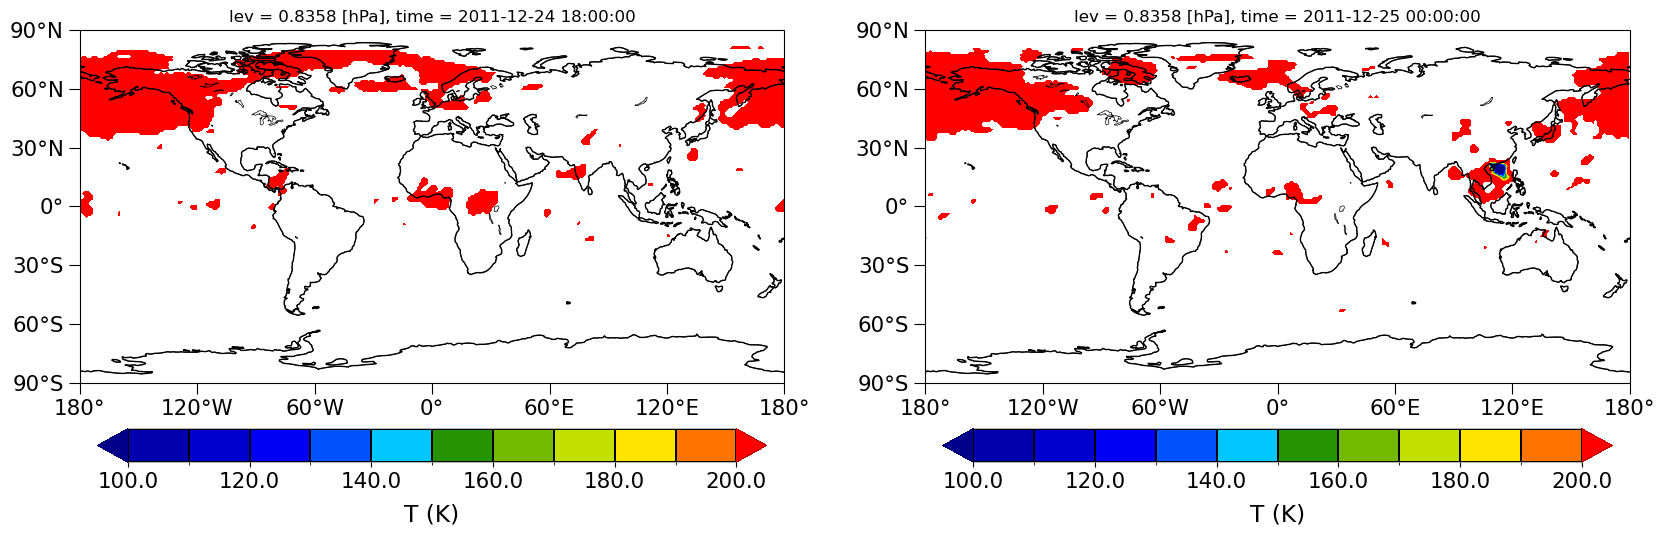

NameError: name 'plot_type' is not defined

In [40]:
if __name__ == "__main__":
    var_dict = {'T' : {'unit': '$^o$C', 'level':np.linspace(-30,20,51),  'ref': "ERA5"}}
    regnam = 'global'
    case = "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.EN01"
    data_path = '/compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/rest/instability_check/post'
    time_tag = ['2011-12-24-64800','2011-12-25-00000']
    var = 'T'
    ilev = 5
    draw_model_bias_2d(case,ilev,regnam,time_tag,var,var_dict[var],data_path,fgw=20,fgh=12,hs=0.2,ws=0.2)
        